# 03 · 균열단면 — 균열모멘트와 유효단면2차모멘트

원 문서의 `cracked_properties.ipynb` 에 대응한다.

| 항목 | 식 | 조문 |
|---|---|---|
| 파괴계수 | $f_r = 0.63\lambda\sqrt{f_{ck}}$ | KDS 14 20 30 4.2.1 |
| 균열모멘트 | $M_{cr} = f_r I_g / y_t$ | KDS 14 20 30 식 (4.2-2) |
| 유효단면2차모멘트 | Branson 식 | KDS 14 20 30 식 (4.2-1) |

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

In [2]:
from concreteproperties import ConcreteSection
from sectionproperties.pre.library import concrete_rectangular_section

from concreteproperties_kds import KDS


def beam_section(fck=27, fy=400):
    """400 x 600 보 단면 (상부 2-D16, 하부 4-D22, 피복 50 mm)."""
    kds = KDS(column_type="tie")
    conc = kds.create_concrete_material(compressive_strength=fck)
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=600, b=400,
        dia_top=16, area_top=198.6, n_top=2, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=4, c_bot=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    conc_sec = ConcreteSection(geom)
    kds.assign_concrete_section(conc_sec)
    return kds, conc_sec


def column_section(fck=27, fy=400, column_type="tie"):
    """500 x 500 기둥 단면 (8-D22, 피복 50 mm)."""
    kds = KDS(column_type=column_type)
    conc = kds.create_concrete_material(compressive_strength=fck)
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=500, b=500,
        dia_top=22, area_top=387.1, n_top=3, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=3, c_bot=50,
        dia_side=22, area_side=387.1, n_side=1, c_side=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    conc_sec = ConcreteSection(geom)
    kds.assign_concrete_section(conc_sec)
    return kds, conc_sec

In [3]:
kds, conc_sec = beam_section()
conc = conc_sec.concrete_geometries[0].material

gross = kds.get_transformed_gross_properties(
    elastic_modulus=conc.elastic_modulus
)

cracked = kds.calculate_cracked_properties(theta=0)
cracked.calculate_transformed_properties(
    elastic_modulus=conc.elastic_modulus
)

print(f"파괴계수           fr   = {conc.flexural_tensile_strength:.3f} MPa")
print(f"총단면 2차모멘트   Ig   = {gross.ixx_c:,.0f} mm^4")
print(f"균열모멘트         Mcr  = {cracked.m_cr / 1e6:.2f} kN.m")
print(f"중립축 깊이        d_nc = {cracked.d_nc:.2f} mm")
print(f"균열단면 2차모멘트 Icr  = {cracked.ixx_c_cr:,.0f} mm^4")
print(f"Icr / Ig                = {cracked.ixx_c_cr / gross.ixx_c:.3f}")

파괴계수           fr   = 3.274 MPa
총단면 2차모멘트   Ig   = 7,912,837,641 mm^4
균열모멘트         Mcr  = 88.42 kN.m
중립축 깊이        d_nc = 146.93 mm
균열단면 2차모멘트 Icr  = 2,226,509,867 mm^4
Icr / Ig                = 0.281


## 유효단면2차모멘트 (Branson 식)

$$I_e = \left(\frac{M_{cr}}{M_a}\right)^3 I_g
+ \left[1 - \left(\frac{M_{cr}}{M_a}\right)^3\right] I_{cr} \le I_g$$

KDS 14 20 30 식 (4.2-1)

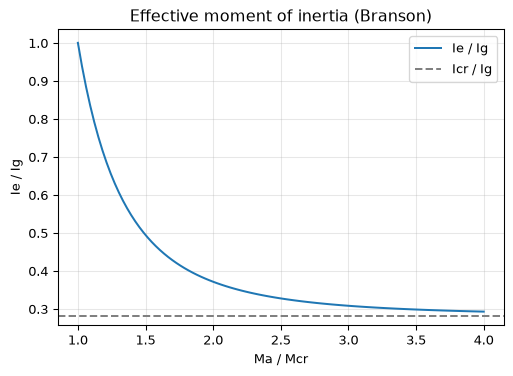

In [4]:
from concreteproperties_kds import effective_moment_of_inertia

ratios = np.linspace(1.0, 4.0, 100)
i_e = [
    effective_moment_of_inertia(
        m_a=r * cracked.m_cr, m_cr=cracked.m_cr,
        i_g=gross.ixx_c, i_cr=cracked.ixx_c_cr,
    )
    for r in ratios
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ratios, np.array(i_e) / gross.ixx_c, label="Ie / Ig")
ax.axhline(
    cracked.ixx_c_cr / gross.ixx_c, ls="--", color="grey", label="Icr / Ig"
)
ax.set_xlabel("Ma / Mcr")
ax.set_ylabel("Ie / Ig")
ax.set_title("Effective moment of inertia (Branson)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

모멘트가 커질수록 $I_e$ 가 $I_{cr}$ 로 수렴한다.

## 균열단면 응력

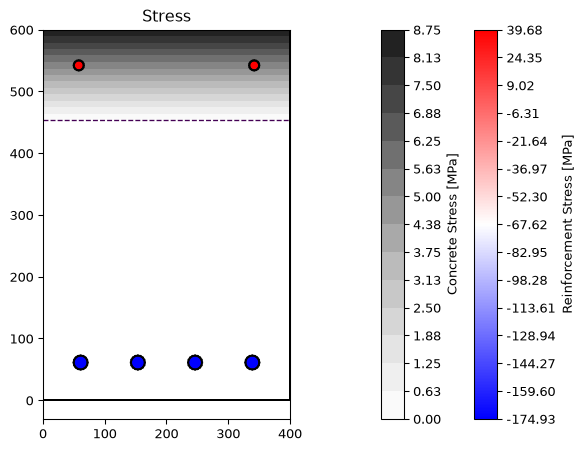

<Axes: title={'center': 'Stress'}>

In [5]:
stress = kds.calculate_cracked_stress(
    cracked_results=cracked, m=1.5 * cracked.m_cr
)
stress.plot_stress()